## TP FINAL INTELIGENCIA ARTIFICIAL

Autores: Juan Manuel Meneghini, Lucas Starita

Coautor: J.A.R.V.I.S 🧠

Tema elegido: Red convolucional para estimación de una magnitud (regresión)

Version 11: Usa la arquitectura de CNN 1D + Transformers desarrollada en verisiones previas. Usamos el meschiset.


In [1]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers, models
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

import pandas as pd
import wfdb                 # para trabajar con señales fisiológicas
import numpy as np
import os
from tqdm import tqdm       # para visualizar progresos
import concurrent.futures
from google.colab import drive
from google.colab import files


In [2]:
# ============================================================
# 1) MONTAR DRIVE + CONFIG
# ============================================================
drive.mount("/content/drive", force_remount=False)
TFRECORD_FILE = "/content/drive/MyDrive/Proyecto_Final_IA_Starita_Meneghini/output.tfrecord"

AUTOTUNE = tf.data.AUTOTUNE

# ============================================================
# 2) DEFINICIÓN DEL TFEXAMPLE (solo una vez)
# ============================================================
feature_description = {
    "data":        tf.io.VarLenFeature(tf.float32),
    "age":         tf.io.FixedLenFeature([], tf.float32),
    "vent_rate":   tf.io.FixedLenFeature([], tf.int64),
    "sex":         tf.io.FixedLenFeature([], tf.string),
    "qrs":         tf.io.FixedLenFeature([], tf.int64),
    "pr_interval": tf.io.FixedLenFeature([], tf.int64),
    "QT":          tf.io.FixedLenFeature([], tf.int64),
    "QTc":         tf.io.FixedLenFeature([], tf.int64),
    "P":           tf.io.FixedLenFeature([], tf.int64),
}

META_KEYS = ["vent_rate", "qrs", "pr_interval", "QT", "QTc", "P"]

# ============================================================
# 3) PARSER — NO NORMALIZA NADA
# ============================================================
def _parse_fn(example_proto):
    f = tf.io.parse_single_example(example_proto, feature_description)

    # ECG sin normalizar
    x = tf.sparse.to_dense(f["data"])
    x = tf.reshape(x, (12, 640))
    x = tf.transpose(x, perm=[1, 0])  # (640, 12)

    # Edad real
    age = tf.cast(f["age"], tf.float32)

    # Metadata numérica
    meta_vals = [tf.cast(f[k], tf.float32) for k in META_KEYS]
    meta_numeric = tf.stack(meta_vals, axis=0)

    # Sexo (Male = 1, Female = 0)
    sex_val = tf.where(tf.equal(f["sex"], b"Male"), 1.0, 0.0)
    sex_val = tf.reshape(sex_val, [1])

    # Meta completa (7 features)
    meta = tf.concat([meta_numeric, sex_val], axis=0)

    return x, meta, age

# ============================================================
# 4) CARGAR DATASET — UNA SOLA VEZ
# ============================================================
parsed_ds = tf.data.TFRecordDataset(TFRECORD_FILE).map(_parse_fn, num_parallel_calls=AUTOTUNE)

# ============================================================
# 5) CONTAR MUESTRAS
# ============================================================
TOTAL = parsed_ds.reduce(tf.constant(0, tf.int64), lambda acc, _: acc + 1).numpy()
TOTAL = int(TOTAL)
print(f"Total muestras: {TOTAL}")

# Shuffle reproducible antes del split
parsed_ds = parsed_ds.shuffle(TOTAL, reshuffle_each_iteration=False)

# ============================================================
# 6) SPLIT
# ============================================================
train_size = int(TOTAL * 0.70)
val_size   = int(TOTAL * 0.15)
test_size  = TOTAL - train_size - val_size

train_base = parsed_ds.take(train_size)
val_base   = parsed_ds.skip(train_size).take(val_size)
test_base  = parsed_ds.skip(train_size + val_size).take(test_size)

# ============================================================
# 7) CALCULAR ESTADÍSTICAS SOLO EN TRAIN
# ============================================================
print("Calculando estadísticas de Train...")

ages_list = []
meta_list = []

for x, m, a in train_base:
    ages_list.append(a.numpy())
    meta_list.append(m.numpy())

ages_arr = np.array(ages_list, dtype=np.float32)
meta_arr = np.array(meta_list, dtype=np.float32)

# Normalización edad (z-score)
AGE_MEAN = ages_arr.mean()
AGE_STD  = ages_arr.std()

# Versiones TF para usarlas dentro de los grafos
AGE_MEAN_TF = tf.constant(AGE_MEAN, dtype=tf.float32)
AGE_STD_TF  = tf.constant(AGE_STD, dtype=tf.float32)

# Normalización meta
meta_mean = meta_arr.mean(axis=0)
meta_std  = meta_arr.std(axis=0)
meta_std_safe = np.where(meta_std < 1e-6, 1.0, meta_std)

print(f"Edad Media: {AGE_MEAN:.2f}, Std: {AGE_STD:.2f}")


# ============================================================
# 8) CALCULAR SAMPLE WEIGHTS (INVERSA DE FRECUENCIA)
# ============================================================
print("Calculando sample weights por inversa de frecuencia...")

# Bins de 0 a 100 en pasos de 5
bins = np.arange(0, 101, 5, dtype=np.float32)  # [0, 5, ..., 100]

# age_bins_indices: cada edad va a un índice de bin (1..len(bins))
age_bins_indices = np.digitize(ages_arr, bins=bins)

# Contar muestras por bin (incluye bin 0, que casi no se usa)
bin_counts = np.bincount(age_bins_indices, minlength=len(bins) + 1)

# Frecuencia relativa por bin
total = bin_counts.sum()
freq = bin_counts.astype(np.float32) / max(total, 1)

eps = 1e-6
raw_weights = 1.0 / (freq + eps)

# Ignoramos bin 0 (edades < 0, en la práctica vacío)
raw_weights[0] = 1.0

# Normalizar pesos para que el promedio (sobre bins con datos) sea ~1
valid = bin_counts > 0
mean_w = raw_weights[valid].mean()
raw_weights = raw_weights / mean_w

# Limitar rango de pesos para evitar explosiones numéricas
weights_manual = np.clip(raw_weights, 0.5, 4.0)

# Constantes para TF
N_BINS = len(weights_manual)
WEIGHTS_TF = tf.constant(weights_manual, dtype=tf.float32)

print("Pesos generados por bin:")
for i, (cnt, w) in enumerate(zip(bin_counts, weights_manual)):
    print(f"  Bin {i:02d}: peso = {w:.4f}, count = {cnt}")



# ============================================================
# 9) NORMALIZACIÓN — SOLO AQUÍ (1 sola vez)
# ============================================================
def normalize_all(x, meta, age):

    # Normalizar ECG (por lead)
    mean = tf.reduce_mean(x, axis=0, keepdims=True)
    std  = tf.math.reduce_std(x, axis=0, keepdims=True)
    x = (x - mean) / (std + 1e-6)

    # Normalizar metadata (usa estadísticas de train, numpy → tf)
    meta_norm = (meta - meta_mean) / meta_std_safe

    # --- Target: edad en z-score ---
    # y = (age - AGE_MEAN) / AGE_STD
    y = (age - AGE_MEAN_TF) / AGE_STD_TF

    return x, meta_norm, y

# Aplicar normalización a splits
train_norm = train_base.map(normalize_all, num_parallel_calls=AUTOTUNE)
val_norm   = val_base.map(normalize_all,   num_parallel_calls=AUTOTUNE)
test_norm  = test_base.map(normalize_all,  num_parallel_calls=AUTOTUNE)


# ============================================================
# 10) OPTIONAL: EXPORT A NUMPY (no obligatorio para training)
# ============================================================
def ds_to_numpy(ds):
    X_list, meta_list, y_list = [], [], []
    for x, meta, age in ds:
        X_list.append(x.numpy())
        meta_list.append(meta.numpy())
        y_list.append(age.numpy())
    return (
        np.array(X_list, dtype=np.float32),
        np.array(meta_list, dtype=np.float32),
        np.array(y_list, dtype=np.float32),
    )

def to_multimodal(x, meta, y):
    return (x, meta), y


def add_sample_weight_robust(inputs, y):
    x, meta = inputs

    # Reconstruir edad real desde z-score
    age_real = y * AGE_STD_TF + AGE_MEAN_TF

    # Bin de 5 años: 0–4 → bin 0/1, 5–9 → bin 1/2, etc.
    age_clipped = tf.clip_by_value(age_real, 0.0, 100.0)
    age_int = tf.cast(age_clipped, tf.int32)

    # Índice de bin: 0..N_BINS-1 (cada 5 años)
    age_bin = age_int // 5
    age_bin = tf.clip_by_value(age_bin, 0, N_BINS - 1)

    weight = tf.gather(WEIGHTS_TF, age_bin)

    return (x, meta), y, weight


X_train, meta_train, y_train = ds_to_numpy(train_norm)
X_val,   meta_val,   y_val   = ds_to_numpy(val_norm)
X_test,  meta_test,  y_test  = ds_to_numpy(test_norm)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total muestras: 24913
Calculando estadísticas de Train...
Edad Media: 34.40, Std: 24.08
Calculando sample weights por inversa de frecuencia...
Pesos generados por bin:
  Bin 00: peso = 0.5000, count = 0
  Bin 01: peso = 0.5000, count = 2672
  Bin 02: peso = 0.5000, count = 1281
  Bin 03: peso = 0.5000, count = 1015
  Bin 04: peso = 0.5000, count = 938
  Bin 05: peso = 0.5000, count = 779
  Bin 06: peso = 0.5000, count = 933
  Bin 07: peso = 0.5000, count = 1207
  Bin 08: peso = 0.5000, count = 1093
  Bin 09: peso = 0.5000, count = 1094
  Bin 10: peso = 0.5000, count = 955
  Bin 11: peso = 0.5000, count = 981
  Bin 12: peso = 0.5000, count = 1057
  Bin 13: peso = 0.5000, count = 1076
  Bin 14: peso = 0.5000, count = 1023
  Bin 15: peso = 0.5000, count = 707
  Bin 16: peso = 0.5000, count = 422
  Bin 17: peso = 0.5000, count = 125
  Bin 18: peso = 0.7048, count

In [3]:
# CONVERSIÓN A TS.DATA.DATASET

BATCH = 32
AUTOTUNE = tf.data.AUTOTUNE

# ============================
# TRAIN
# ============================
train_final = (
    train_norm
        .shuffle(2000)   # <-- CORREGIDO: shuffle primero
        .map(to_multimodal, num_parallel_calls=AUTOTUNE)
        .map(add_sample_weight_robust, num_parallel_calls=AUTOTUNE)
        .batch(BATCH)
        .prefetch(AUTOTUNE)
)

# ============================
# VALIDATION
# ============================
val_final = (
    val_norm
        .map(to_multimodal, num_parallel_calls=AUTOTUNE)
        .batch(BATCH)
        .prefetch(AUTOTUNE)
)

# ============================
# TEST
# ============================
test_final = (
    test_norm
        .map(to_multimodal, num_parallel_calls=AUTOTUNE)
        .batch(BATCH)
        .prefetch(AUTOTUNE)
)


In [4]:
# ============================================================
# BLOQUE RESNET (igual que antes) (V final)
# ============================================================

def ResBlock(x, filters, kernel=7):
    shortcut = x

    x = layers.Conv1D(filters, kernel, padding="same",
                      kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("gelu")(x)

    x = layers.Conv1D(filters, kernel, padding="same",
                      kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x)

    # ajustar canales si hace falta
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, 1, padding="same",
                                 kernel_initializer="he_normal")(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation("gelu")(x)

    return x


# ============================================================
# BLOQUE TRANSFORMER
# ============================================================

def TransformerBlock(x, num_heads=4, key_dim=32, dff=256, dropout_rate=0.1):
    dim = x.shape[-1]  # canales actuales

    # Multi-Head Attention (Pre-Norm)
    ln1 = layers.LayerNormalization()(x)
    attn = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=key_dim,
        dropout=dropout_rate
    )(ln1, ln1)
    attn = layers.Dropout(dropout_rate)(attn)
    x = layers.Add()([x, attn])

    # Feed Forward Network (Pre-Norm)
    ln2 = layers.LayerNormalization()(x)
    ffn = layers.Dense(dff, activation="gelu")(ln2)
    ffn = layers.Dropout(dropout_rate)(ffn)
    ffn = layers.Dense(dim)(ffn)
    x = layers.Add()([x, ffn])

    return x


# ============================================================
# MODELO V3 CON WAVEGRAM BRANCH
# ============================================================

def build_optimal_model_v3_wavegram(seq_len=640, meta_dim=7, l2_reg=1e-5):

    # --------------------------
    # 1) INPUT ECG
    # --------------------------
    ecg_input = layers.Input(shape=(seq_len, 12), name="ecg")

    # ==========================
    # CAMINO A: Conv + ResNet + Transformer
    # ==========================

    # CONV STEM
    x = layers.Conv1D(
        64, 7, padding="same",
        activation="gelu",
        kernel_initializer="he_normal"
    )(ecg_input)

    x = layers.MaxPooling1D(2)(x)   # 640 -> 320

    x = ResBlock(x, 64)
    x = layers.MaxPooling1D(2)(x)   # 320 -> 160 (subo un poco la resolución)

    x = ResBlock(x, 128)
    x = layers.MaxPooling1D(2)(x)   # 160 -> 80 (ideal p/Transformer)

    # --- Positional Embedding learnable ---
    seq_len_reduced = x.shape[1]          # debería ser 80
    d_model = x.shape[-1]                 # canales, 128

    pos_emb_layer = layers.Embedding(
        input_dim=int(seq_len_reduced),
        output_dim=int(d_model)
    )

    positions = tf.range(start=0, limit=int(seq_len_reduced), delta=1)
    pos_encoding = pos_emb_layer(positions)          # (L, d_model)
    pos_encoding = tf.expand_dims(pos_encoding, 0)   # (1, L, d_model)

    x = x + pos_encoding  # broadcasting sobre batch

    # --- 2 bloques Transformer ---
    x = TransformerBlock(x, num_heads=4, key_dim=32, dff=256)
    x = TransformerBlock(x, num_heads=4, key_dim=32, dff=256)

    # Global pooling del camino A
    avg_main = layers.GlobalAveragePooling1D()(x)
    max_main = layers.GlobalMaxPooling1D()(x)
    main_features = layers.Concatenate()([avg_main, max_main])  # ~256 dims

    # ==========================
    # CAMINO B: Wavegram CNN (rama paralela)
    # ==========================

    w = layers.Conv1D(
        32, 3, padding="same",
        activation="gelu",
        kernel_initializer="he_normal"
    )(ecg_input)
    w = layers.Conv1D(
        32, 3, padding="same",
        activation="gelu",
        kernel_initializer="he_normal"
    )(w)
    w = layers.MaxPooling1D(2)(w)       # 640 -> 320

    w = layers.Conv1D(
        64, 3, padding="same",
        activation="gelu",
        kernel_initializer="he_normal"
    )(w)
    w = layers.MaxPooling1D(2)(w)       # 320 -> 160

    # Global pooling del wavegram
    w_avg = layers.GlobalAveragePooling1D()(w)
    w_max = layers.GlobalMaxPooling1D()(w)
    wave_features = layers.Concatenate()([w_avg, w_max])   # ~128 dims

    # ==========================
    # 3) FUSIÓN DE FEATURES ECG (MAIN + WAVEGRAM)
    # ==========================
    ecg_features = layers.Concatenate(name="ecg_features")(
        [main_features, wave_features]
    )  # ~384 dims

    # ==========================
    # 4) BRANCH DE METADATA
    # ==========================
    if meta_dim is not None:
        meta_in = layers.Input(shape=(meta_dim,), name="meta")

        m = layers.LayerNormalization()(meta_in)
        m = layers.Dense(32, activation="gelu")(m)
        m = layers.Dense(16, activation="gelu")(m)
        m = layers.Dense(8,  activation="gelu")(m)

        features = layers.Concatenate(name="fusion_ecg_meta")(
            [ecg_features, m]
        )
        inputs = [ecg_input, meta_in]
    else:
        features = ecg_features
        inputs = ecg_input

    # ==========================
    # 5) REGRESOR FINAL (edad en z-score)
    # ==========================
    reg = tf.keras.regularizers.l2(l2_reg)

    x = layers.LayerNormalization()(features)
    x = layers.Dense(128, activation="gelu", kernel_regularizer=reg)(x)
    x = layers.Dropout(0.1)(x)
    x = layers.Dense(64,  activation="gelu", kernel_regularizer=reg)(x)
    x = layers.Dense(32,  activation="gelu", kernel_regularizer=reg)(x)

    output = layers.Dense(1, kernel_regularizer=reg, name="age_zscore")(x)

    model = tf.keras.Model(inputs, output, name="ECG_Transformer_v3_Wavegram")
    return model


# instanciar
model = build_optimal_model_v3_wavegram(seq_len=640, meta_dim=7)
model.summary()


Model: "ECG_Transformer_v3_Wavegram"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ecg (InputLayer)    │ (None, 640, 12)   │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 640, 64)   │      5,440 │ ecg[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 320, 64)   │          0 │ conv1d[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 320, 64)   │     28,736 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 320, 64)   │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 320, 64)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 320, 64)   │     28,736 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 320, 64)   │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 320, 64)   │          0 │ batch_normalizat… │
│                     │                   │            │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 320, 64)   │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 160, 64)   │          0 │ activation_1[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 160, 128)  │     57,472 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 160, 128)  │        512 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 160, 128)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 160, 128)  │    114,816 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 160, 128)  │        512 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 160, 128)  │      8,320 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 160, 128)  │          0 │ batch_normalizat… │
│                     │                   │            │ conv1d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 160, 128)  │          0 │ add_1[0][0]       │
│ (Activation)        │                   │            │                 

 Total params: 582,903 (2.22 MB)

 Trainable params: 582,135 (2.22 MB)

 Non-trainable params: 768 (3.00 KB)

In [ ]:
# @title
# ============================================================
# BLOQUE RESNET (lo dejamos casi igual, sólo bajamos filtros en el modelo)
# ============================================================

def ResBlock(x, filters, kernel=7):
    shortcut = x

    x = layers.Conv1D(filters, kernel, padding="same",
                      kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("gelu")(x)

    x = layers.Conv1D(filters, kernel, padding="same",
                      kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x)

    # ajustar canales si hace falta
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, 1, padding="same",
                                 kernel_initializer="he_normal")(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation("gelu")(x)

    return x


# ============================================================
# BLOQUE TRANSFORMER OPTIMIZADO PARA 640×12
# - Menos heads
# - key_dim fijo (32)
# - dff más chico
# ============================================================

def TransformerBlock(x, num_heads=4, key_dim=32, dff=256, dropout_rate=0.1):

    dim = x.shape[-1]  # canales actuales

    # Multi-Head Attention
    ln1 = layers.LayerNormalization()(x)
    attn = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=key_dim,
        dropout=dropout_rate
    )(ln1, ln1)
    attn = layers.Dropout(dropout_rate)(attn)
    x = layers.Add()([x, attn])

    # Feed Forward Network
    ln2 = layers.LayerNormalization()(x)
    ffn = layers.Dense(dff, activation="gelu")(ln2)
    ffn = layers.Dropout(dropout_rate)(ffn)
    ffn = layers.Dense(dim)(ffn)
    x = layers.Add()([x, ffn])

    return x


# ============================================================
# MODELO COMPLETO OPTIMIZADO PARA seq_len=640
# - Menos filtros
# - 2 Transformers
# - Positional Embedding learnable
# - Sin Dropout en el regressor (usamos L2 suave)
# ============================================================

def build_optimal_model_v2(seq_len=640, meta_dim=7, l2_reg=1e-5):

    # --------------------------
    # 1) ECG INPUT
    # --------------------------
    ecg_input = layers.Input(shape=(seq_len, 12), name="ecg")

    # CONV STEM más liviano
    x = layers.Conv1D(
        64, 7, padding="same",
        activation="gelu",
        kernel_initializer="he_normal"
    )(ecg_input)

    x = layers.MaxPooling1D(2)(x)   # 640 -> 320

    x = ResBlock(x, 64)
    x = layers.MaxPooling1D(4)(x)   # 320 -> 80

    x = ResBlock(x, 128)
    x = layers.MaxPooling1D(2)(x)   # 80 -> 40 (ideal p/Transformer)

    # --------------------------
    # 1.5) POSITIONAL ENCODING LEARNABLE
    # --------------------------
    seq_len_reduced = x.shape[1]          # debería ser 40
    d_model = x.shape[-1]                 # canales, 128

    # Embedding de posición (0..seq_len_reduced-1)
    pos_emb_layer = layers.Embedding(
        input_dim=int(seq_len_reduced),
        output_dim=int(d_model)
    )

    positions = tf.range(start=0, limit=int(seq_len_reduced), delta=1)
    pos_encoding = pos_emb_layer(positions)          # (seq_len_reduced, d_model)
    pos_encoding = tf.expand_dims(pos_encoding, 0)   # (1, seq_len_reduced, d_model)

    x = x + pos_encoding  # broadcasting sobre el batch

    # --------------------------
    # 2) TRANSFORMER STACK (2 bloques)
    # --------------------------
    x = TransformerBlock(x, num_heads=4, key_dim=32, dff=256)
    x = TransformerBlock(x, num_heads=4, key_dim=32, dff=256)

    # --------------------------
    # 3) GLOBAL FEATURES
    # --------------------------
    avg = layers.GlobalAveragePooling1D()(x)
    mx  = layers.GlobalMaxPooling1D()(x)
    features = layers.Concatenate()([avg, mx])  # ~256 dims

    # --------------------------
    # 4) METADATA BRANCH
    # --------------------------
    if meta_dim is not None:
        meta_in = layers.Input(shape=(meta_dim,), name="meta")

        m = layers.LayerNormalization()(meta_in)
        m = layers.Dense(32, activation="gelu")(m)
        m = layers.Dense(16, activation="gelu")(m)
        m = layers.Dense(8,  activation="gelu")(m)

        features = layers.Concatenate()([features, m])
        inputs = [ecg_input, meta_in]
    else:
        inputs = ecg_input

    # --------------------------
    # 5) FINAL REGRESSOR (sin Dropout, con L2 suave)
    # --------------------------
    reg = tf.keras.regularizers.l2(l2_reg)

    x = layers.Dense(128, activation="gelu", kernel_regularizer=reg)(features)
    x = layers.Dropout(0.1)(x)
    x = layers.Dense(64,  activation="gelu", kernel_regularizer=reg)(x)
    x = layers.Dense(32,  activation="gelu", kernel_regularizer=reg)(x)

    # Salida: 1 valor = edad en z-score
    output = layers.Dense(1, kernel_regularizer=reg)(x)

    model = tf.keras.Model(inputs, output, name="ECG_Transformer_v2")
    return model


# instanciar
model = build_optimal_model_v2(seq_len=640, meta_dim=7)
model.summary()


In [5]:
## ENTRENAMIENTO ##

# Huber Loss (suave entre MSE para errores chicos y MAE para errores grandes)
loss_fn = tf.keras.losses.Huber(delta=1.0)
# delta = 1 equivale aproximadamente a 1 desviación estándar del target (≈ 24 años reales)

optimizer = tf.keras.optimizers.Adam(
    learning_rate=1e-4,
    beta_1=0.9,
    beta_2=0.98,
    global_clipnorm=1.0
)

model.compile(
    optimizer=optimizer,
    loss=loss_fn,   # <--- reemplaza "mse" por Huber Loss
    metrics=["mae"]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=12,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        patience=5,
        factor=0.5,
        min_lr=1e-6
    )
]

history = model.fit(
    train_final,
    validation_data=val_final,
    epochs=60,
    callbacks=callbacks
)


Epoch 1/60
    545/Unknown 88s 71ms/step - loss: 0.1348 - mae: 0.5909

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


545/545 ━━━━━━━━━━━━━━━━━━━━ 105s 103ms/step - loss: 0.1347 - mae: 0.5907 - val_loss: 0.1453 - val_mae: 0.4059 - learning_rate: 1.0000e-04
Epoch 2/60
545/545 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0706 - mae: 0.3926 - val_loss: 0.1158 - val_mae: 0.3518 - learning_rate: 1.0000e-04
Epoch 3/60
545/545 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0585 - mae: 0.3505 - val_loss: 0.1112 - val_mae: 0.3498 - learning_rate: 1.0000e-04
Epoch 4/60
545/545 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0495 - mae: 0.3179 - val_loss: 0.1033 - val_mae: 0.3332 - learning_rate: 1.0000e-04
Epoch 5/60
545/545 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0442 - mae: 0.2983 - val_loss: 0.1014 - val_mae: 0.3232 - learning_rate: 1.0000e-04
Epoch 6/60
545/545 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0394 - mae: 0.2790 - val_loss: 0.1069 - val_mae: 0.3317 - learning_rate: 1.0000e-04
Epoch 7/60
545/545 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0357 - mae: 0.2634 - val_loss: 0.1112 - val_mae: 0.3355 - learn

117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Total de muestras originales: 3738
Muestras utilizadas tras filtrar >100 años: 3686

RESULTADOS (sin edades >100 años):
MAE  = 7.5528 años
RMSE = 10.5868 años
R²   = 0.7978


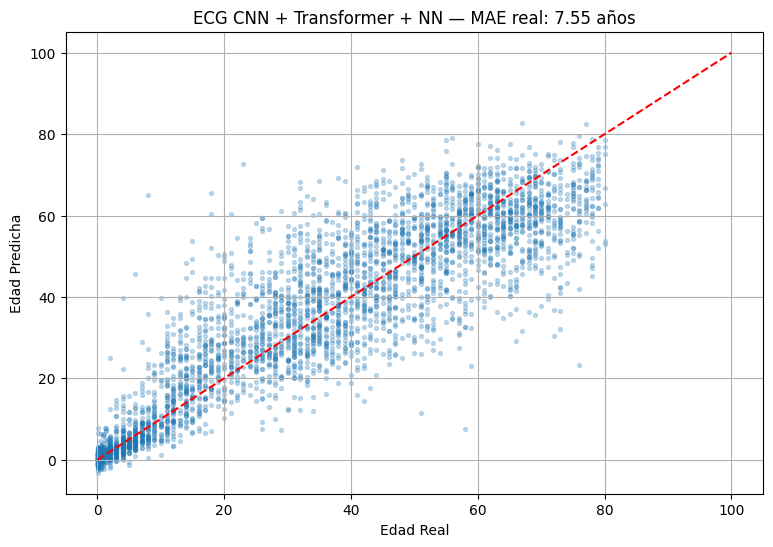

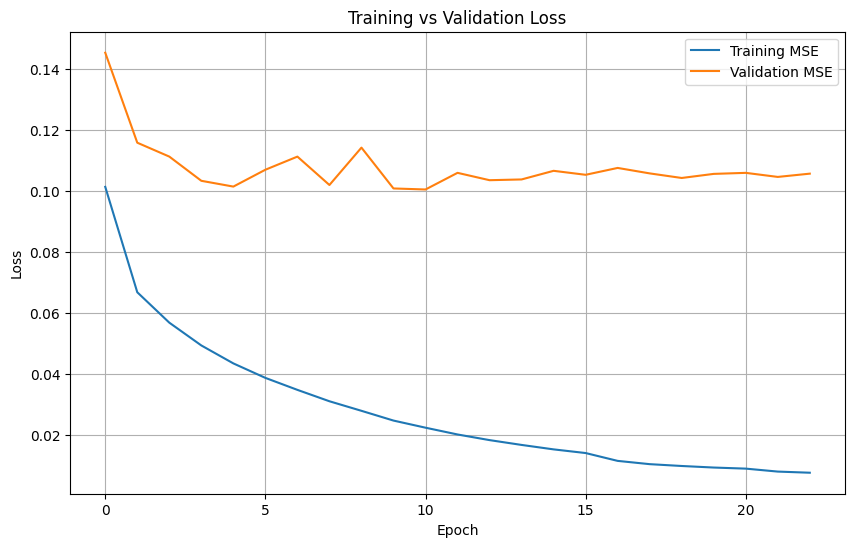

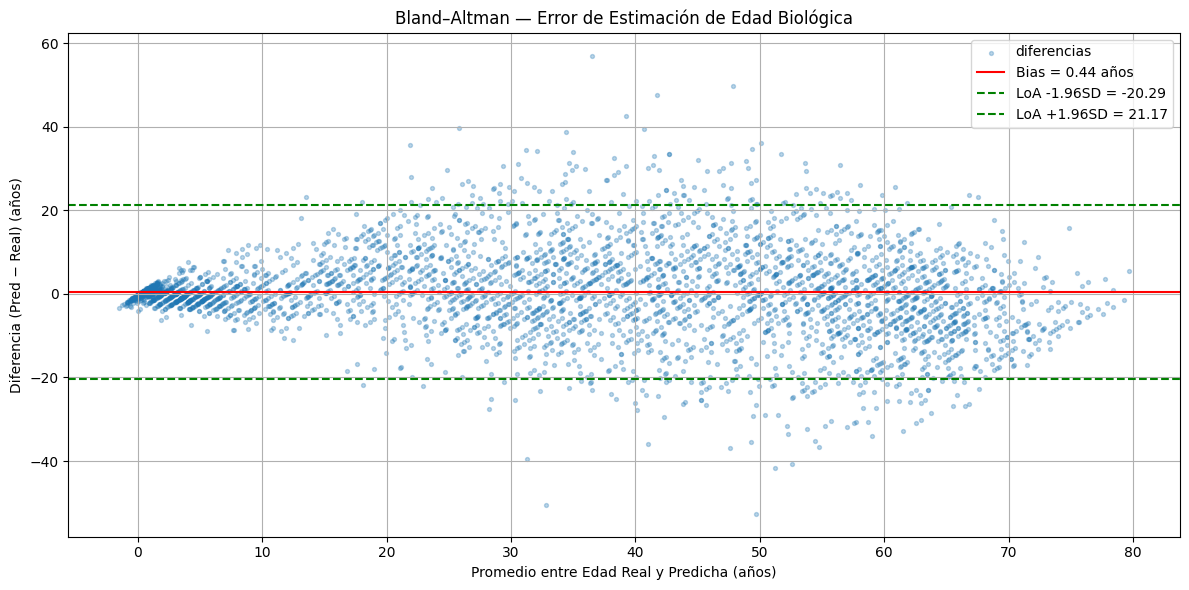

In [12]:
## EVALUACIÓN FINAL ##

# Convertir test_final → NumPy (más rápido y limpio)
X_ecg_list = []
X_meta_list = []
y_list = []

for (ecg, meta), y in test_final.unbatch():
    X_ecg_list.append(ecg.numpy())
    X_meta_list.append(meta.numpy())
    y_list.append(y.numpy())

X_ecg  = np.array(X_ecg_list, dtype=np.float32)
X_meta = np.array(X_meta_list, dtype=np.float32)
y_true_norm = np.array(y_list, dtype=np.float32).flatten()

# Predicciones NORMALIZADAS (z-score)
y_pred_norm = model.predict([X_ecg, X_meta], verbose=1).flatten()

# === Desnormalización correcta: z-score → edad real ===
y_pred = y_pred_norm * AGE_STD + AGE_MEAN
y_true = y_true_norm * AGE_STD + AGE_MEAN

# ------------------------------------------------------
# 🔥 FILTRO: excluir casos con edad REAL > 100 años
# ------------------------------------------------------
mask = y_true <= 80

y_true = y_true[mask]
y_pred = y_pred[mask]
X_ecg  = X_ecg[mask]
X_meta = X_meta[mask]

print(f"Total de muestras originales: {len(y_list)}")
print(f"Muestras utilizadas tras filtrar >100 años: {len(y_true)}")
# ------------------------------------------------------

# Métricas REALES
mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2   = r2_score(y_true, y_pred)

print("\nRESULTADOS (sin edades >100 años):")
print(f"MAE  = {mae:.4f} años")
print(f"RMSE = {rmse:.4f} años")
print(f"R²   = {r2:.4f}")

# =========================================
# GRÁFICO 1 — Nube de puntos pred vs real
# =========================================
plt.figure(figsize=(9, 6))
plt.scatter(y_true, y_pred, alpha=0.25, s=8)
plt.plot([0, 100], [0, 100], 'r--')
plt.xlabel("Edad Real")
plt.ylabel("Edad Predicha")
plt.title(f"ECG CNN + Transformer + NN — MAE real: {mae:.2f} años")
plt.grid(True)
plt.show()

# =========================================
# GRÁFICO 2 — Curvas de entrenamiento
# =========================================
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training MSE')
plt.plot(history.history['val_loss'], label='Validation MSE')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# =========================================
# GRÁFICO 3 — Bland–Altman Plot
# =========================================

means = (y_true + y_pred) / 2
diffs = y_pred - y_true   # pred - real

bias = np.mean(diffs)
loa_1 = bias - 1.96 * np.std(diffs)
loa_2 = bias + 1.96 * np.std(diffs)

plt.figure(figsize=(12, 6))
plt.scatter(means, diffs, alpha=0.3, s=8, label="diferencias")
plt.axhline(bias, color='red', linestyle='-', label=f"Bias = {bias:.2f} años")
plt.axhline(loa_1, color='green', linestyle='--', label=f"LoA -1.96SD = {loa_1:.2f}")
plt.axhline(loa_2, color='green', linestyle='--', label=f"LoA +1.96SD = {loa_2:.2f}")

plt.xlabel("Promedio entre Edad Real y Predicha (años)")
plt.ylabel("Diferencia (Pred − Real) (años)")
plt.title("Bland–Altman — Error de Estimación de Edad Biológica")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


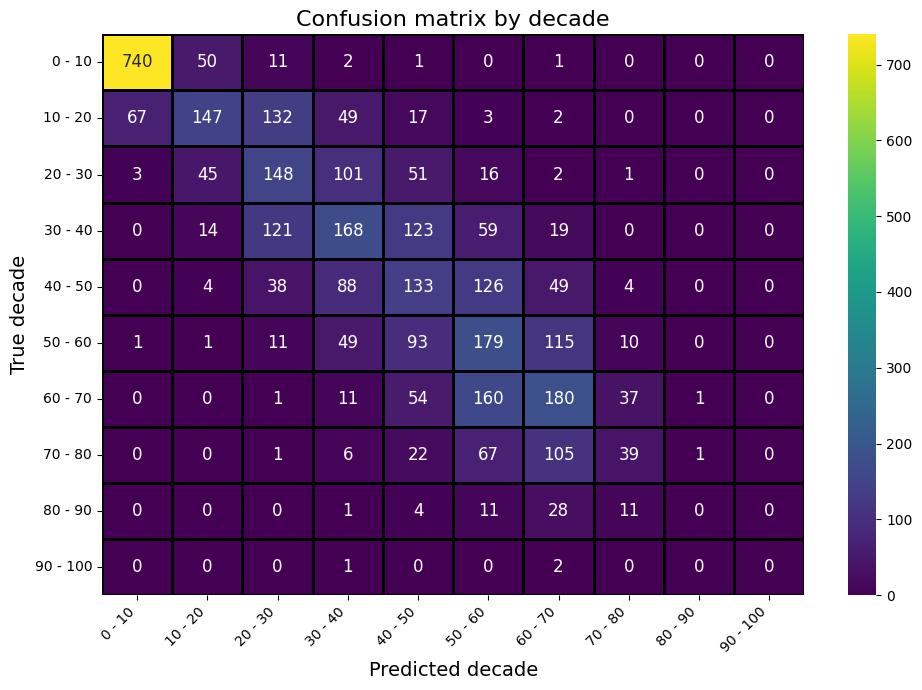

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ============================
# 1) Crear bins por décadas
# ============================

bins = np.arange(0, 110, 10)  # 0,10,20,...,100
labels = [f"{i} - {i+10}" for i in range(0, 100, 10)]

# Convertir edades reales y predichas a bins (0=0-10, 1=10-20, ...)
true_bins = np.digitize(y_true, bins) - 1
pred_bins = np.digitize(y_pred, bins) - 1

# Clip para evitar índices fuera de rango
true_bins = np.clip(true_bins, 0, len(labels)-1)
pred_bins = np.clip(pred_bins, 0, len(labels)-1)

# ============================
# 2) Matriz de confusión
# ============================
cm = confusion_matrix(true_bins, pred_bins)

# ============================
# 3) Plot estilo the one you showed
# ============================

plt.figure(figsize=(10, 7))
ax = sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="viridis",
    linewidths=1,
    linecolor="black",
    cbar=True,
    xticklabels=labels,
    yticklabels=labels,
    annot_kws={"size": 12}
)

plt.xlabel("Predicted decade", fontsize=14)
plt.ylabel("True decade", fontsize=14)
plt.title("Confusion matrix by decade", fontsize=16)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


mejor resultado
RESULTADOS:
MAE  = 8.8034
RMSE = 10.9795
R²   = 0.7945

In [39]:
print("Rango edad:", np.min(ages_arr), np.max(ages_arr))
print("Primeros 200 valores:", ages_arr[:200])
print("Valores únicos raros:", np.unique(ages_arr[ages_arr < 0]))
print("Valores > 120:", ages_arr[ages_arr > 120][:50])



Rango edad: 0.010958904 124.0
Primeros 200 valores: [3.50000000e+01 4.70000000e+01 4.70000000e+01 6.00000000e+00
 1.08333337e+00 2.70000000e+01 3.10000000e+01 3.33333343e-01
 6.20000000e+01 2.50000000e+01 4.00000000e+01 5.90000000e+01
 2.40000000e+01 1.53846160e-01 2.20000000e+01 6.00000000e+01
 1.60000000e+01 5.20000000e+01 1.41666663e+00 5.90000000e+01
 4.00000000e+01 5.76923080e-02 2.00000000e+00 1.08333337e+00
 4.00000000e+01 4.00000000e+01 3.00000000e+01 5.30000000e+01
 4.00000000e+00 1.80000000e+01 7.60000000e+01 2.20000000e+01
 3.30000000e+01 2.20000000e+01 2.90000000e+01 7.80000000e+01
 6.40000000e+01 1.10000000e+01 5.20000000e+01 1.15384616e-01
 6.40000000e+01 3.40000000e+01 3.90000000e+01 1.70000000e+01
 1.90000000e+01 8.33333313e-01 5.90000000e+01 2.30000000e+01
 4.70000000e+01 6.20000000e+01 4.00000000e+00 3.70000000e+01
 7.20000000e+01 6.00000000e+00 3.00000000e+00 2.90000000e+01
 2.50000000e+01 3.00000000e+01 4.00000000e+01 5.00000000e+00
 1.60000000e+01 6.40000000e+01 5.